# Занятие 31. Мини-тест: решающее дерево

Короткая проверка теории. Типы заданий: сопоставление, выбор ответа, открытый ответ, вычисление / код, по картинке.

В ячейках с кодом заполните пропуски (`...`), чтобы проверки `assert` прошли.


## 1. Части решающего дерева

**Тип:** сопоставление

**Задание.** Сопоставьте часть дерева с её ролью.

**Варианты для сопоставления:**

A. Корень  
B. Внутренний узел  
C. Лист

1. узел, где модель выдаёт ответ (класс или число)  
2. вершина, с которой начинается путь объекта  
3. узел, где задаётся вопрос вида «признак ≤ порог?»

**Правильный ответ:** A-2, B-3, C-1.


## 2. Чистый лист и Gini

**Тип:** выбор ответа

**Задание.** В листе только один класс. Чему равна неопределённость (impurity) по Gini?

**Варианты ответа:**

A. Максимально возможной.  
B. Нулю: смесь классов исчезла.  
C. Обязательно отрицательной.  
D. Равной accuracy всего дерева.

**Правильный ответ:** B.


## 3. Выбор split по Gini

**Тип:** вычисление / код

**Задание.** Узел `[0,0,1,1]`. Split L: `[0,0]` / `[1,1]`. Split M: `[0,1]` / `[0,1]`.  
Gini бинарный: $2p(1-p)$. Какой split лучше (меньше взвешенный Gini)?

**Правильный ответ:** лучше split L, взвешенный Gini `0` против `0.5` (assert).


In [ ]:
def gini(labels):
    n = len(labels)
    p = sum(labels) / n
    return 2 * p * (1 - p)

def weighted(left, right):
    n = len(left) + len(right)
    return (len(left) * gini(left) + len(right) * gini(right)) / n

gL = weighted([0, 0], [1, 1])
gM = weighted([0, 1], [0, 1])
better = ...  # "L" или "M"

assert abs(gL - 0.0) < 1e-12
assert abs(gM - 0.5) < 1e-12
assert better == "L"
print("ok", gL, gM, better)


## 4. Вероятность в листе

**Тип:** вычисление / код

**Задание.** Лист `[1,1,1,0]`. Вероятность класса 1 и класс при пороге 0.5?

**Правильный ответ:** вероятность класса 1 равна `0.75`, класс `1` (assert).


In [ ]:
proba_1 = ...
pred = ...
assert abs(proba_1 - 0.75) < 1e-12
assert pred == 1
print("ok", proba_1, pred)


## 5. Глубина и переобучение

**Тип:** выбор ответа

**Задание.** При росте `max_depth` качество на train стремится к 1.0, а на validation падает. Что это?

**Варианты ответа:**

A. Модель универсально лучше.  
B. Оценка на validation всегда посчитана неверно.  
C. Похоже на переобучение.  
D. Глубина не влияет на сложность.

**Правильный ответ:** C.


## 6. min_samples_leaf

**Тип:** выбор ответа

**Задание.** Зачем увеличивать `min_samples_leaf`?

**Варианты ответа:**

A. Запретить использование признаков.  
B. Чтобы лист опирался на больше объектов и меньше ловил шум.  
C. Чтобы превратить дерево в линейную регрессию.  
D. Чтобы заменить классификацию регрессией.

**Правильный ответ:** B.


## 7. Граница по картинке

**Тип:** по картинке

**Задание.**

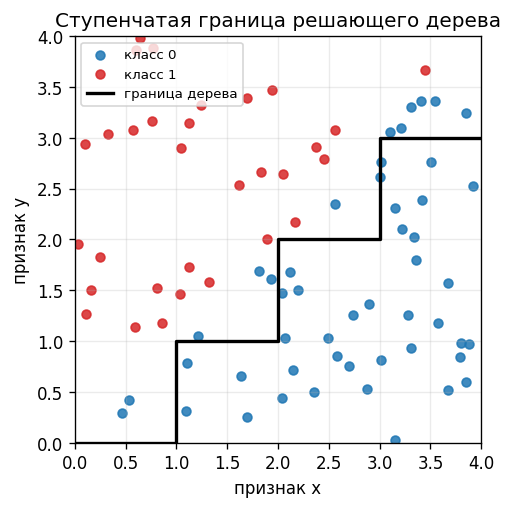

Почему граница дерева выглядит «ступеньками», даже если классы разделены примерно по диагонали?

**Правильный ответ:** разбиения вида `признак ≤ порог` дают границы, параллельные осям.


## 8. Масштабирование и дерево

**Тип:** выбор ответа

**Задание.** Нужен ли обычно `StandardScaler` перед обычным деревом решений?

**Варианты ответа:**

A. Да, иначе дерево не запустится.  
B. Обычно нет: пороги по одному признаку не требуют общего масштаба как у kNN/линейных моделей с регуляризацией.  
C. Да, иначе Gini становится отрицательным.  
D. Scaler нужен только если признаков меньше трёх.

**Правильный ответ:** B.


## 9. Feature importance

**Тип:** выбор ответа

**Задание.** Высокая importance (важность) у признака `доход`. Доказывает ли это причинность?

**Варианты ответа:**

A. Нет: это полезность признака для разбиений модели, а не доказательство причины.  
B. Да, всегда.  
C. Да, если дерево глубокое.  
D. Нет, потому что деревья не считают importance (важность).

**Правильный ответ:** A.


## 10. Жадный split

**Тип:** открытый ответ

**Задание.** Почему лучший локальный split «прямо сейчас» не гарантирует лучшее дерево целиком?

**Формат ответа:** 1–3 предложения.

**Правильный ответ:** дерево строят жадно: хороший текущий шаг не обязан вести к глобально лучшему дереву.
